<a href="https://colab.research.google.com/github/oxedanda/pml_final_project/blob/main/02_modeling_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this section, we prepare the data for the first predictive model. The target is annual wine production, and the predictors are region, campaign year, and vineyard area. Missing values in vineyard area will be handled inside the modeling pipeline.

In [1]:
!git clone https://github.com/oxedanda/pml_final_project.git

Cloning into 'pml_final_project'...
remote: Enumerating objects: 111, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 111 (delta 44), reused 42 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (111/111), 502.84 KiB | 8.67 MiB/s, done.
Resolving deltas: 100% (44/44), done.


In [3]:
# Practical Machine Learning Final Project
# Predicting Annual Wine Production by Viticultural Region in Portugal

from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [4]:
# File paths
DATA_DIR = Path("/content/pml_final_project/data/processed")

PRODUCTION_FILE = DATA_DIR / "wine_production_by_region_clean.csv"
AREA_FILE = DATA_DIR / "vineyard_area_by_region_clean.csv"

# Load cleaned datasets
production = pd.read_csv(PRODUCTION_FILE)
area = pd.read_csv(AREA_FILE)

# Merge datasets
df = production.merge(
    area,
    on=["region", "year_start"],
    how="left"
)

print("Production shape:", production.shape)
print("Area shape:", area.shape)
print("Merged shape:", df.shape)

display(df.head())

Production shape: (238, 8)
Area shape: (288, 3)
Merged shape: (238, 9)


,region,campaign_year,year_start,total_production_hl,dop_production_hl,igp_production_hl,year_variety_production_hl,non_certified_production_hl,vineyard_area_ha
0,Alentejo,2009/10,2009,810338,356783,449833,995,2728,23490.0
1,Algarve,2009/10,2009,23650,4680,11797,0,7173,1983.0
2,Açores,2009/10,2009,13754,2771,2832,6,8145,1700.0
3,Bairrada,2009/10,2009,246705,69459,64138,1068,112041,NaN
4,Beira Interior,2009/10,2009,192084,50158,20570,14,121342,NaN


In [5]:
# Target variable
target = "total_production_hl"

# Features for the first model
feature_columns = [
    "region",
    "year_start",
    "vineyard_area_ha",
]

X = df[feature_columns].copy()
y = df[target].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Features shape: (238, 3)
Target shape: (238,)


,region,year_start,vineyard_area_ha
0,Alentejo,2009,23490.0
1,Algarve,2009,1983.0
2,Açores,2009,1700.0
3,Bairrada,2009,NaN
4,Beira Interior,2009,NaN


,total_production_hl
0,810338
1,23650
2,13754
3,246705
4,192084


In [6]:
# Check missing values in the modeling features
print("Missing values in features:")
display(X.isna().sum().to_frame("missing_count"))

print("\nFeature types:")
display(X.dtypes.to_frame("dtype"))

Missing values in features:


,missing_count
region,0
year_start,0
vineyard_area_ha,38



Feature types:


,dtype
region,object
year_start,int64
vineyard_area_ha,float64


In [7]:
# Chronological Split and Preprocessing Pipeline

# Sort by time to respect the temporal structure of the problem
df_sorted = df.sort_values(["year_start", "region"]).reset_index(drop=True)

X = df_sorted[feature_columns].copy()
y = df_sorted[target].copy()

# Use the last 3 campaign years as the test set
test_years = sorted(df_sorted["year_start"].unique())[-3:]

train_data = df_sorted[~df_sorted["year_start"].isin(test_years)].copy()
test_data = df_sorted[df_sorted["year_start"].isin(test_years)].copy()

X_train = train_data[feature_columns]
y_train = train_data[target]
X_test = test_data[feature_columns]
y_test = test_data[target]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Test years:", test_years)

# Preprocessing
numeric_features = ["year_start", "vineyard_area_ha"]
categorical_features = ["region"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# Baseline model
model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regressor", LinearRegression()),
    ]
)

Train shape: (196, 3)
Test shape: (42, 3)
Test years: [np.int64(2023), np.int64(2024), np.int64(2025)]


In [8]:
# Train the Model and Evaluate

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.4f}")

MAE: 80,649.69
RMSE: 116,422.76
R²: 0.9464


In [9]:
results = X_test.copy()
results["actual"] = y_test.values
results["predicted"] = y_pred
results["error"] = results["actual"] - results["predicted"]

display(results.head(10))

,region,year_start,vineyard_area_ha,actual,predicted,error
196,Alentejo,2023,26443.0,1233148,1.104641e+06,128506.583827
197,Algarve,2023,1355.0,16613,4.204705e+04,-25434.046050
198,Açores,2023,1737.0,8007,3.564560e+04,-27638.595145
199,Bairrada,2023,9440.0,251051,2.613120e+05,-10260.981730
200,Beira Interior,2023,11738.0,185805,2.451646e+05,-59359.630263
201,Douro,2023,44224.0,1561729,1.465986e+06,95743.086973
202,Dão,2023,12898.0,281210,3.085657e+05,-27355.689103
203,Lisboa,2023,17857.0,1539151,1.119030e+06,420121.079571
204,Madeira,2023,669.0,37800,6.767213e+04,-29872.125651
205,P. Setúbal,2023,7417.0,589897,4.948691e+05,95027.943714


## Results Interpretation

The baseline linear regression model provides a reasonable first approximation of annual wine production by region. In several cases, the predicted values are in the same general range as the observed values, which suggests that the selected features capture part of the production pattern.

However, the prediction errors remain noticeable for some regions and years. This is expected because the model uses only three predictors: region, year, and vineyard area. Wine production is influenced by additional factors such as weather conditions, disease pressure, management practices, and other regional characteristics that are not included in the current dataset.

Overall, this baseline model is useful as a reference point for the project. It establishes a simple and interpretable benchmark that can later be compared with more flexible models or richer feature sets.

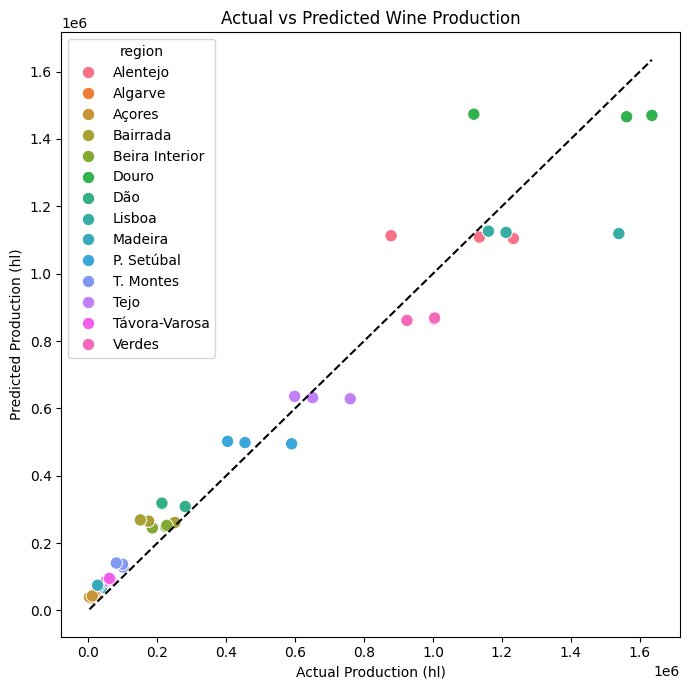

In [10]:
# Actual vs Predicted Plot

import matplotlib.pyplot as plt
import seaborn as sns

results = X_test.copy()
results["actual"] = y_test.values
results["predicted"] = y_pred
results["error"] = results["actual"] - results["predicted"]

plt.figure(figsize=(7, 7))
sns.scatterplot(data=results, x="actual", y="predicted", hue="region", s=80)

min_val = min(results["actual"].min(), results["predicted"].min())
max_val = max(results["actual"].max(), results["predicted"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black")
plt.title("Actual vs Predicted Wine Production")
plt.xlabel("Actual Production (hl)")
plt.ylabel("Predicted Production (hl)")
plt.tight_layout()
plt.show()

The actual-versus-predicted plot shows how closely the model estimates match the observed production values. Points near the diagonal line indicate accurate predictions, while points farther away highlight regions or years where the model performs less well.

## Model Evaluation

The baseline model was evaluated on the most recent campaign years to respect the temporal structure of the problem. The main metrics used were MAE, RMSE, and R².

In [12]:
# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.4f}")

metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2"],
    "value": [mae, rmse, r2]
})

display(metrics)

MAE: 80,649.69
RMSE: 116,422.76
R²: 0.9464


,metric,value
0,MAE,80649.687213
1,RMSE,116422.760819
2,R2,0.946353


## Evaluation Summary

The baseline linear regression model performs well overall. The MAE of about 80,650 hectoliters means that, on average, the predictions differ from the observed production values by that amount. The RMSE is larger because it penalizes larger errors more strongly. The R² value of 0.9464 indicates that the model explains most of the variation in wine production in the test years.

Some prediction errors remain, which suggests that other relevant factors are still missing from the model.

## Final Conclusion

This notebook built a baseline model for predicting annual wine production by region in Portugal. The results show that region, year, and vineyard area already explain most of the variation, but future models could improve performance by adding more explanatory variables.